In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
data = sns.load_dataset('diamonds')

In [5]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
data.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [9]:
for col in data.columns:
  if not is_numeric_dtype(data[col]):
    print(data[col].value_counts())

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [11]:
#  encode the dataset
ord = OrdinalEncoder()
for col in data.columns:
  if not is_numeric_dtype(data[col]):
    data[col]= ord.fit_transform(data[[col]])

In [12]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2.0,1.0,3.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,1.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,1.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,5.0,5.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,6.0,3.0,63.3,58.0,335,4.34,4.35,2.75


In [13]:
df = data.copy()

In [14]:
x= df.drop(["price"], axis=1)
y= df[['price']]

In [15]:
x.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,2.0,1.0,3.0,61.5,55.0,3.95,3.98,2.43
1,0.21,3.0,1.0,2.0,59.8,61.0,3.89,3.84,2.31
2,0.23,1.0,1.0,4.0,56.9,65.0,4.05,4.07,2.31
3,0.29,3.0,5.0,5.0,62.4,58.0,4.20,4.23,2.63
4,0.31,1.0,6.0,3.0,63.3,58.0,4.34,4.35,2.75


In [16]:
x.shape

(53940, 9)

In [17]:
y.shape

(53940, 1)

In [34]:
# object creation
lr = LinearRegression()
knn_lr = KNeighborsRegressor()
dtr = DecisionTreeRegressor()

In [19]:
kfold = KFold()
skfold = StratifiedKFold()

In [20]:
# model Implementation
cv_model = cross_val_score(knn_lr, x, y, cv=kfold)

In [21]:
cv_model

array([-0.07021663,  0.2098233 ,  0.60299146, -2.0178209 , -1.06200375])

In [22]:
cv_model.mean()

np.float64(-0.4674453060620166)

In [23]:
cv_model = cross_val_score(lr, x, y, cv=kfold)

In [24]:
cv_model

array([ -0.10596482,   0.5324201 ,   0.77578324, -13.41382813,
        -0.78816908])

In [25]:
cv_model.mean()

np.float64(-2.5999517391397435)

In [26]:
cv_model = cross_val_score(lr, x, y, cv=skfold)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [27]:
cv_model

array([0.88949601, 0.88347798, 0.8893923 , 0.88735625, 0.87007931])

In [28]:
cv_model.mean()

np.float64(0.8839603709620711)

<Axes: >

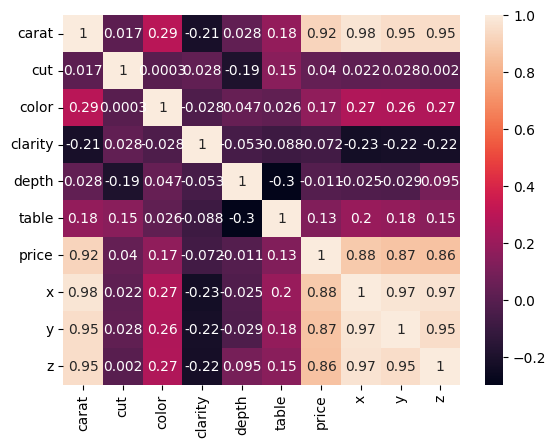

In [31]:
sns.heatmap(df.corr(), annot=True)

In [35]:
cv_model = cross_val_score(dtr, x, y, cv=kfold)

In [37]:
cv_model.mean()

np.float64(-0.12882812109866376)

In [38]:
cv_model = cross_val_score(dtr, x, y, cv=skfold)
cv_model.mean()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


np.float64(0.9647294078956442)

# Hyper Parameter Optimization

In [ ]:
# parameter
dic = {}

In [ ]:
# grid search
gd_ser = GridSearchCV(dtr)